In [1]:
# -*- coding: utf-8 -*-
"""
Ambit demo as python file.
Remember to change the COM port on line ~80
"""

import numpy as np
import serial
import time
import matplotlib.pyplot as plt
from IPython import display
plt.style.use("dark_background")


In [2]:

#helper functions
# plot autoscale
def autoscale(data: list, axis:plt.Axes):
    if len(data) == 0: return
    if len(data) == 1: 
        axis.set_ylim([data[0]-1, data[0]+1])
        return    
    l, h = axis.get_ylim()
    x, d = np.min(data), np.max(data)
    r = d - x

    _l, _h, a = l, h, False
    if (x < l) or (l < x - r):
        _l = x - 0.05 * r
        a = True
    if (d > h) or (h > l + r):
        _h = d + 0.05 * r
        a = True
    if a and _l != _h:
        axis.set_ylim([_l, _h])

# convert protocol to ambit array
def gen_cmd_arr_line(num:int, freq:int, actinic:int)->list:
    return [2, 0, num//256, num%256, freq//256, freq%256, actinic, 1]


# flatten ambit array, calc time, actinic array
def calc_arr_param(cmd: list, persist:bool = False):
    cmd_arr = np.reshape(cmd, (-1, 8))
    arr_length = cmd_arr.shape[0]
    cmd_str = "arrun1," + str(arr_length) + "," + str(persist) + ","+ str(cmd)[1:-1] + ",\n"
    cmd_str = cmd_str.replace(" ", "")

    num_pts = cmd_arr[:, 2] * 256 + cmd_arr[:, 3]
    act_arr = cmd_arr[:, 6]
    mea_feq = 1 / (cmd_arr[:, 4] * 256 + cmd_arr[:, 5])
    _t, mea_tml, mea_act = 0, [], []
    for _n, _f, _a in zip(num_pts, mea_feq, act_arr):
        mea_tml += (np.arange(_n) * _f + _t).tolist()
        mea_act += [_a] * _n
        _t = mea_tml[-1]
    mea_tml = np.array(mea_tml) * 0.854
    return cmd_str, mea_tml, mea_act




In [5]:
###############################################################################

# create a trace with 3 different setups:
# 1. 50 points, 10Hz, no actinic
# 2. 50 points, 50Hz, 240/255(max) actinic
# 3. 50 points, 10Hz, no actinic
# number of lines (1 - 8) points(10 - 2000), freq (1 - 200), actinic 0 - 255

cmd = []
cmd += gen_cmd_arr_line(num = 5, freq = 10, actinic = 0)
cmd += gen_cmd_arr_line(num = 80, freq = 100, actinic = 200)
cmd += gen_cmd_arr_line(num = 5, freq = 10, actinic = 0)

# convert to command for ambit, also pre-calculate the time and actinic of each point
cmd_str, timeline, act_arr = calc_arr_param(cmd, 0)

cmd_str

'arrun1,3,0,2,0,0,5,0,10,0,1,2,0,0,80,0,100,200,1,2,0,0,5,0,10,0,1,\n'

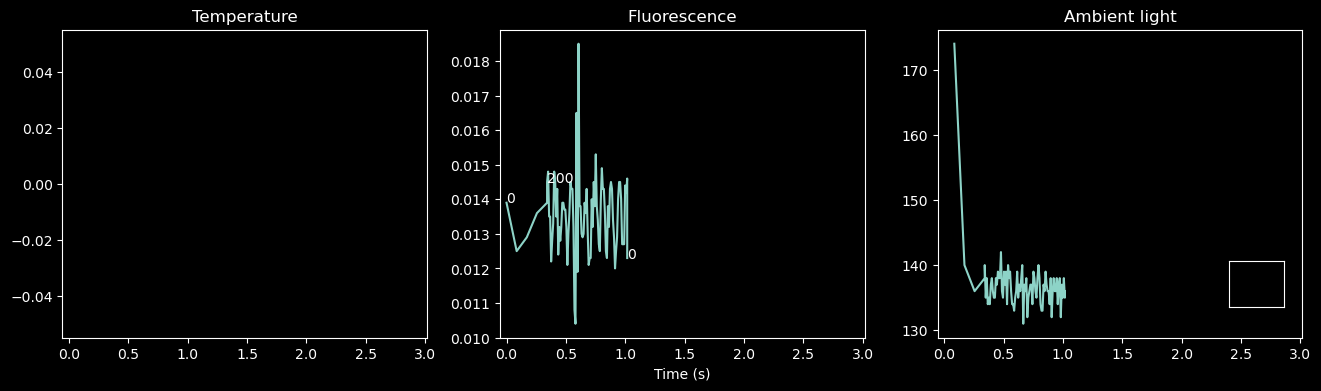

In [6]:


###############################################################################

TIMEOUT = 2
ambit_port = "COM28"  #<----change to ambit port


fig, axes = plt.subplots(1, 3, sharex = True, figsize = (16, 4))
x = [] # x axis
d_temp, d_fluo, d_ambient = [], [], []
axes[0].set_title("Temperature")
axes[1].set_title("Fluorescence")
axes[2].set_title("Ambient light")
axes[1].set_xlabel('Time (s)')

l_temp = axes[0].plot(0)
l_fluo = axes[1].plot(0)
l_ambient = axes[2].plot(0)


ax_spec = axes[2].inset_axes([0.8, 0.1, 0.15, 0.15])
ax_spec.set_xticks([])
ax_spec.set_yticks([])


# get spectrometer data
with serial.Serial(ambit_port, baudrate=115200, timeout = 1) as ser:
    ser.setRTS(False)
    ser.write("get_par".encode())
    _ = ser.readline()
    par = ser.readline().decode()
    spec = ser.readline().decode()
    if len(spec) > 10 and str.count(spec, ',') == 9:
        spec = np.fromstring(spec, sep = ',', dtype= int)
        ax_spec.bar([415, 445, 480,515, 555, 590, 630, 680, 850], spec[:9] + [spec[-1]], width = [30, 30, 30, 40, 40, 40, 60, 60, 100], color = ['indigo','blue','royalblue','c','lime','gold','orange','red','darkred'])


# run PAM
# with serial.Serial(ambit_port, baudrate=115200) as ser:
    watchdog_timer_t = time.time()
    ser.write(cmd_str.encode())
    _str = ''
    data_counter = 0
    _line = ''
    run_msg = ''
    new_data = []
    last_plot = time.time()
    pre_act = -1
    while time.time() < watchdog_timer_t + TIMEOUT:
        # readlines from serial
        if ser.in_waiting > 0:
            c = ser.read()
            if (c > bytes([0])) and (c < bytes([128])):
                watchdog_timer_t = time.time()
                _str += c.decode()
                if (c == b"\n") or (c == b"\r"):
                    _line = _str
                    _str = ''
                    if ("T:" in _line) and (",L:" in _line): # line contains data
                        new_data = [float(n.split(':')[1]) for n in _line.strip('\n').split(',')]
                        data_counter += 1
                    elif ("Done") in _line:
                        TIMEOUT = 0
                    else:
                        run_msg += _line # error msg if any

        if len(new_data) == 6: # add data to lists
            x.append(timeline[data_counter - 1])
            d_temp.append(new_data[0])
            d_fluo.append(new_data[1])
            d_ambient.append(new_data[4] - 500) # this offset can be different for different ambits
            # if actinic intensity changed, plot it on middle figure
            if pre_act != act_arr[data_counter - 1]: 
                axes[1].text(x[-1], d_fluo[-1], str(act_arr[data_counter - 1]))
                pre_act = act_arr[data_counter - 1]
            new_data = []


        # update the figure, plotting takes time, so lower the plotting frequency when data are coming in high rate
        if (ser.in_waiting > 50 and time.time() - last_plot > .95) or (ser.in_waiting < 50 and time.time() - last_plot > .6):
            if data_counter < 2: continue

            last_plot = time.time()
            _xlim_left, _xlim_right = axes[0].get_xlim()            
            if x[-1] >= _xlim_right - 2: axes[0].set_xlim([_xlim_left, x[-1] + 2])
            autoscale(d_temp, axes[0])
            autoscale(d_fluo, axes[1])
            autoscale(d_ambient[1:], axes[2])
            l_temp[0].set_xdata(x)
            l_temp[0].set_ydata(d_temp)
            l_fluo[0].set_xdata(x)
            l_fluo[0].set_ydata(d_fluo)

            # ambient data #1 is also off...
            l_ambient[0].set_xdata(x[1:])
            l_ambient[0].set_ydata(d_ambient[1:])


            display.display(fig)
            display.clear_output(True)


